# Análisis Exploratorio de Datos: caso aplicado
## Dataset Palmer Penguins

**CLCD 121 — Ciencia de Datos · Módulo 3**

En este notebook desarrollamos un AED completo de principio a fin sobre un dataset real, aplicando los conceptos vistos en clase: tipos de datos, valores faltantes, análisis univariado, bivariado y multivariado, correlaciones y visualizaciones según el tipo de variable.

## Sobre el dataset

El **Palmer Penguins dataset** contiene mediciones de 344 pingüinos de tres especies (Adelie, Chinstrap y Gentoo) registrados en tres islas del archipiélago Palmer, en la Antártida, entre 2007 y 2009. Fue propuesto por la Dra. Kristen Gorman como alternativa al clásico dataset Iris.

Las variables son:

- `species`: especie del pingüino (Adelie, Chinstrap, Gentoo)
- `island`: isla donde fue observado (Biscoe, Dream, Torgersen)
- `bill_length_mm`: largo del pico, en milímetros
- `bill_depth_mm`: profundidad del pico, en milímetros
- `flipper_length_mm`: largo de la aleta, en milímetros
- `body_mass_g`: peso corporal, en gramos
- `sex`: sexo (male, female)
- `year`: año de observación


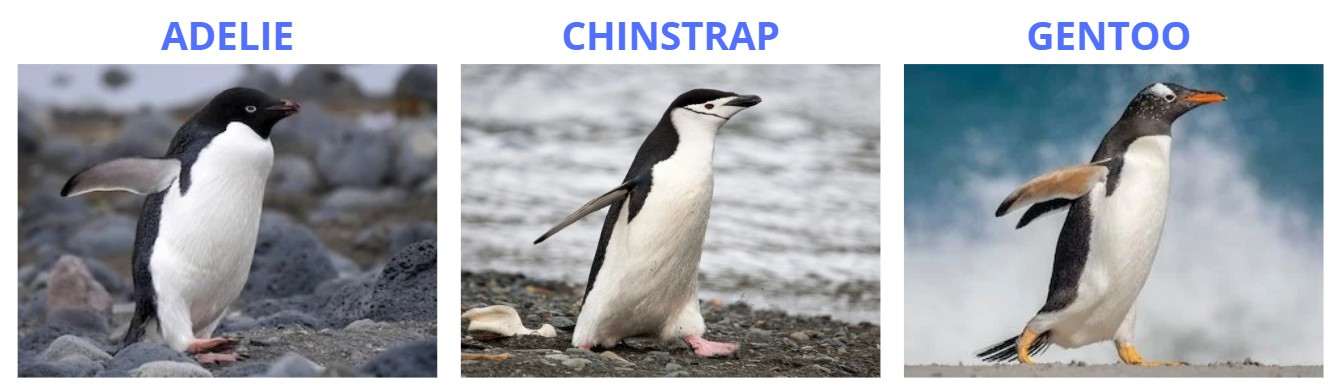
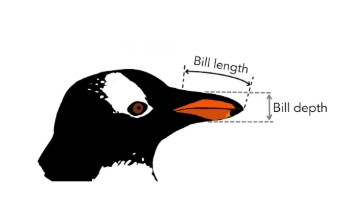

## Objetivo del análisis

Explorar el dataset para responder preguntas como: ¿en qué se diferencian las tres especies? ¿hay diferencias entre machos y hembras? ¿están las especies distribuidas uniformemente en las islas? ¿qué variables se relacionan entre sí?

## Índice

1. Preparación e inspección inicial
2. Análisis de calidad de los datos
3. Análisis univariado
4. Análisis bivariado
5. Análisis multivariado y correlaciones
6. Síntesis y próximos pasos
7. Ejercicios

---
# 1. Preparación e inspección inicial

## 1.1 Importación de librerías

Cargamos las librerías que vamos a usar a lo largo del análisis: `pandas` para manipular datos, `numpy` para cálculos numéricos, y `matplotlib` y `seaborn` para visualización.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de los gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

# Para mostrar todas las columnas en la salida de pandas
pd.set_option('display.max_columns', None)

## 1.2 Carga del dataset

El dataset está disponible en el paquete `palmerpenguins`. Si no lo tienen instalado, pueden hacerlo con `pip install palmerpenguins`.

In [3]:
pip install palmerpenguins

In [4]:
from palmerpenguins import load_penguins

df = load_penguins()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Cargamos el dataset y mostramos las primeras filas para tener una primera impresión de la estructura. Vemos que cada fila representa un pingüino, y que algunas columnas presentan valores `NaN` ya en las primeras observaciones (fila índice 3): es la primera señal de que vamos a tener que prestar atención a los datos faltantes.

## 1.3 Forma del dataset

Antes de profundizar, conviene saber con cuántas observaciones y variables estamos trabajando.

In [5]:
print(f'Cantidad de filas (observaciones): {df.shape[0]}')
print(f'Cantidad de columnas (variables):  {df.shape[1]}')

Cantidad de filas (observaciones): 344
Cantidad de columnas (variables):  8


Verificamos las dimensiones del dataset: 344 pingüinos y 8 variables. Es un dataset chico cualquier conclusión debe tomarse como exploratoria.


## 1.4 Tipos de datos

Como vimos en clase, el tipo de dato de cada variable condiciona qué análisis tienen sentido. Revisemos qué tipos asignó pandas automáticamente.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


Inspeccionamos los tipos de datos y la cantidad de valores no nulos por columna. Observamos que:

- Las cuatro variables de medición (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) son `float64`: numéricas continuas, ideales para estadísticas descriptivas y boxplots.
- `species`, `island` y `sex` son `object`: en realidad son categóricas, conviene convertirlas al tipo `category` para mejor rendimiento e interpretación.
- `year` es `int64`: aunque numéricamente es entera, conceptualmente funciona más como categórica ordinal.

Algunas columnas tienen menos valores no nulos que el total de filas: hay datos faltantes que vamos a analizar en detalle más adelante.

**Próximo paso**: ajustar los tipos de las variables categóricas.

In [7]:
# Convertimos las columnas categóricas al tipo 'category'
for col in ['species', 'island', 'sex']:
    df[col] = df[col].astype('category')

df.dtypes

,0
species,category
island,category
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,category
year,int64


Convertimos las tres variables categóricas al tipo `category`. Esto no cambia la información, pero le indica a pandas que se trata de variables con un conjunto acotado de valores posibles, lo que mejora el rendimiento al filtrar y agrupar, y nos permite usar funciones específicas para categóricas más adelante.

---
# 2. Análisis de calidad de los datos

Antes de calcular estadísticas o hacer gráficos, conviene asegurarnos de que los datos están en condiciones: revisar valores faltantes, duplicados y posibles inconsistencias.

## 2.1 Valores faltantes

¿Cuántos valores faltantes hay en cada columna?

In [8]:
# Cantidad de valores faltantes por columna
faltantes = df.isna().sum()
porcentaje = (df.isna().sum() / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'cantidad_nulos': faltantes,
    'porcentaje': porcentaje
})
resumen_nulos

,cantidad_nulos,porcentaje
species,0,0.00
island,0,0.00
bill_length_mm,2,0.58
bill_depth_mm,2,0.58
flipper_length_mm,2,0.58
body_mass_g,2,0.58
sex,11,3.20
year,0,0.00


Calculamos la cantidad y el porcentaje de valores faltantes por columna. Las cuatro variables de medición tienen 2 faltantes cada una, y `sex` tiene 11. Las demás columnas están completas.

**Conclusión preliminar**: el porcentaje de faltantes es bajo (menos del 4% en el peor caso), pero conviene investigar si están concentrados en las mismas filas.

In [9]:
# Veamos las filas con al menos un valor faltante
df[df.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,2007
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN,2007
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,2007
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,2008
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,2009
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,2009


Filtramos las filas con al menos un valor faltante. Vemos un patrón importante: hay 2 filas donde **todas las mediciones están vacías** (probablemente registros incompletos), y otras 9 filas donde solo falta el sexo pero las mediciones están disponibles.

**Decisión**: para los análisis univariados podemos seguir trabajando con el dataset completo, ya que pandas ignora los `NaN` en la mayoría de los cálculos. Si más adelante necesitamos un análisis libre de nulos, eliminaremos esas filas con `dropna()`. No imputamos los faltantes porque, al ser pocos, eliminar las filas afectadas tiene un impacto menor en la muestra.

## 2.2 Duplicados

¿Hay observaciones duplicadas?

In [10]:
print(f'Filas duplicadas: {df.duplicated().sum()}')

Filas duplicadas: 0


 Verificamos que no hay filas duplicadas en el dataset. Cada pingüino es un registro único.

---
# 3. Análisis univariado

El análisis univariado consiste en estudiar cada variable de manera aislada, sin relacionarla con las demás. El objetivo es comprender la distribución, la tendencia central y la dispersión de cada una.

Como vimos en clase, las herramientas a usar dependen del tipo de variable.

## 3.1 Variables numéricas: estadísticas descriptivas

Para las cuatro variables continuas, calculamos las medidas resumen estándar.

In [11]:
df.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.00,342.00,342.00,342.00,344.00
mean,43.92,17.15,200.92,4201.75,2008.03
std,5.46,1.97,14.06,801.95,0.82
min,32.10,13.10,172.00,2700.00,2007.00
25%,39.22,15.60,190.00,3550.00,2007.00
50%,44.45,17.30,197.00,4050.00,2008.00
75%,48.50,18.70,213.00,4750.00,2009.00
max,59.60,21.50,231.00,6300.00,2009.00


Generamos un resumen estadístico de las variables numéricas. Algunas observaciones:

- **`bill_length_mm`**: largo del pico entre 32,1 y 59,6 mm, con una media de 43,9. La mediana (44,45) es muy cercana a la media, lo que sugiere una distribución relativamente simétrica.
- **`bill_depth_mm`**: profundidad del pico entre 13,1 y 21,5 mm, con una media de 17,15. La mediana (17,30) es muy cercana a la media, lo que sugiere una distribución relativamente simétrica.
- **`flipper_length_mm`**: largo de la aleta entre 172 y 231 mm. Notar que la diferencia entre el percentil 25 (190) y el 75 (213) es de 23 mm, una variabilidad considerable.
- **`body_mass_g`**: peso entre 2700 y 6300 gramos. La diferencia entre los pingüinos más livianos y los más pesados es de más del doble, lo que anticipa que probablemente haya subgrupos con tamaños distintos.

**Hipótesis preliminar**: la amplia variación en peso, largo del pico y largo de aleta sugiere que el dataset contiene subgrupos diferenciados (probablemente las distintas especies). El análisis bivariado nos permitirá confirmarlo.

## 3.2 Variables numéricas: visualización con histogramas

El histograma es la herramienta natural para visualizar la distribución de una variable numérica continua.

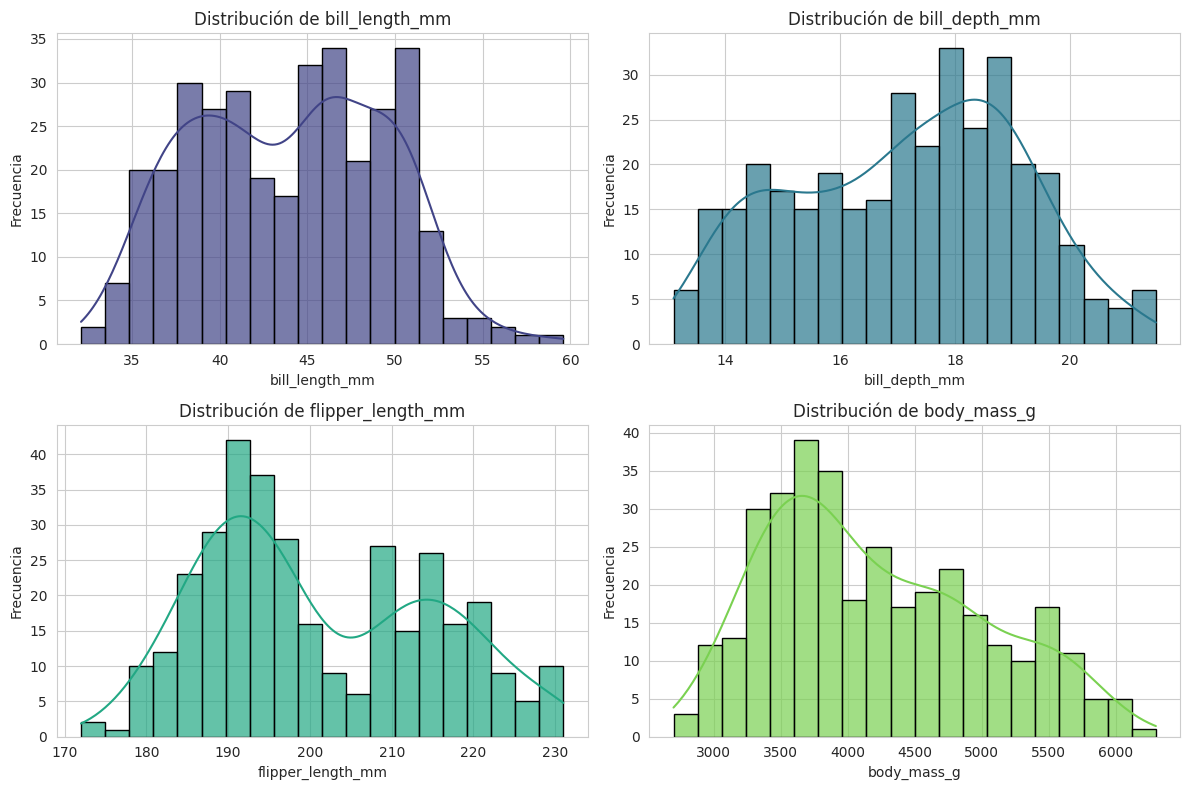

In [18]:
variables_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
colores = sns.color_palette('viridis', n_colors=len(variables_numericas))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, var, color in zip(axes.flatten(), variables_numericas, colores):
    sns.histplot(data=df, x=var, bins=20, kde=True,
                 color=color, edgecolor='black', alpha=0.7, ax=ax)
    ax.set_title(f'Distribución de {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Lo primero que llama la atención es que ninguna de las cuatro variables tiene una distribución simple en forma de campana. En casi todas aparecen dos picos, con un valle en el medio: esto se llama distribución bimodal y es la señal más importante de este análisis univariado.

**`bill_length_mm`**: dos picos bastante separados, uno cerca de los 38-40 mm y otro alrededor de los 46-50 mm. El valle entre ambos es claro.  
**`bill_depth_mm`**: también bimodal, aunque con menos separación. Un grupo tiene picos poco profundos (14-15 mm) y el otro más profundos (18-19 mm).  
**`flipper_length_mm`**: la bimodalidad más pronunciada de las cuatro. Dos grupos muy distintos: aletas cortas (alrededor de 190 mm) y aletas largas (alrededor de 215 mm).  
**`body_mass_g`**: hay un grupo principal cerca de los 3500-4000 g y una segunda elevación más suave alrededor de los 5000-5500 g. La cola se extiende hacia la derecha, lo que indica que hay pingüinos notablemente más pesados que el resto.  

¿Qué nos dice esto?   
Que el dataset no es homogéneo: mezcla pingüinos con características morfológicas distintas. La bimodalidad es una pista fuerte de que hay subgrupos escondidos en los datos. ¿Cuáles? Lo vamos a confirmar en el análisis bivariado cuando incorporemos la variable species.


Una distribución unimodal y simétrica indicaría una población homogénea. La bimodalidad es una pista fuerte de heterogeneidad.

## 3.3 Variables numéricas: detección de outliers con boxplot

Aplicamos el criterio de Tukey para identificar valores atípicos.

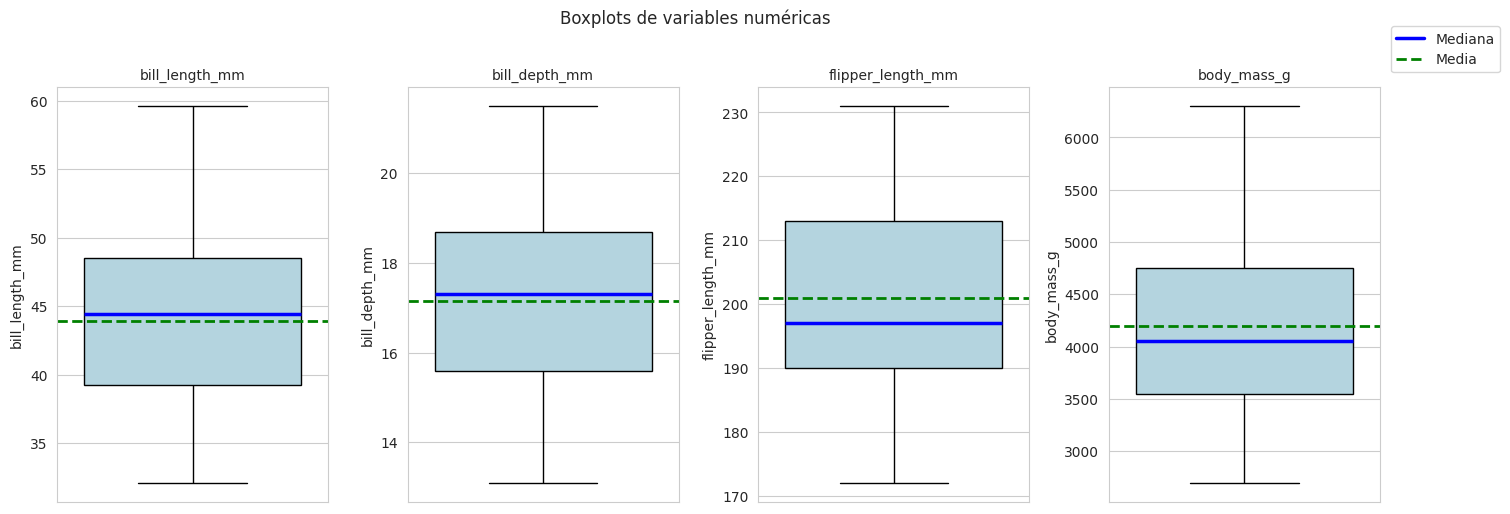

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for ax, var in zip(axes, variables_numericas):
    # Boxplot con seaborn
    sns.boxplot(data=df, y=var, ax=ax,
                color='lightblue',
                medianprops=dict(color='blue', linewidth=2.5),
                boxprops=dict(edgecolor='black'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                flierprops=dict(marker='o', markerfacecolor='gray',
                                markeredgecolor='black', markersize=5))

    # Línea de la media en verde
    media = df[var].mean()
    ax.axhline(media, color='green', linewidth=2, linestyle='--', label='Media')

    ax.set_title(var, fontsize=10)
    ax.set_xlabel('')

# Leyenda
handles = [
    plt.Line2D([0], [0], color='blue',  linewidth=2.5, label='Mediana'),
    plt.Line2D([0], [0], color='green', linewidth=2,   linestyle='--', label='Media')
]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.08, 1))

plt.suptitle('Boxplots de variables numéricas', y=1.02)
plt.tight_layout()
plt.show()

Aplicamos un boxplot a cada variable numérica para detectar valores atípicos según el criterio de Tukey (1,5 × IQR).

Ninguna de las cuatro variables presenta outliers importantes en este análisis univariado. Sin embargo, hay que recordar que el criterio de Tukey supone una sola distribución homogénea. Si los datos están compuestos por subgrupos (las especies), un valor que parece normal en el conjunto global podría ser atípico dentro de su subgrupo, y viceversa. Esto se evaluará mejor con boxplots comparativos por especie.  

`bill_length_mm`: la mediana (44,5 mm) y la media (43,9 mm) están muy cerca y ambas caen en la mitad inferior de la caja, lo que sugiere una leve asimetría hacia la derecha. No hay outliers visibles.  
`bill_depth_mm`: La caja es relativamente amplia (IQR de unos 3 mm), indicando mayor dispersión en el 50% central respecto al largo del pico.  
`flipper_length_mm`: es el boxplot más llamativo. La mediana (197 mm) está claramente en la parte baja de la caja y la media (201 mm) queda por encima, lo que señala una asimetría hacia la derecha más pronunciada. La caja es ancha y los bigotes también: hay mucha variabilidad en esta variable. No hay outliers, pero la asimetría refuerza lo que veíamos en el histograma: hay un grupo con aletas notablemente más largas que "tira" la media hacia arriba.  
`body_mass_g`: la mediana (4050 g) está en la parte baja de la caja y la media (4202 g) queda claramente por encima, confirmando la asimetría hacia la derecha que ya anticipaban el histograma. Hay pingüinos considerablemente más pesados que el grueso del conjunto.


## 3.4 Variables categóricas: frecuencias

Para las variables categóricas, contamos la frecuencia de cada categoría.

In [15]:
for col in ['species', 'island', 'sex']:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False))
    print()

--- species ---
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

--- island ---
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

--- sex ---
sex
male      168
female    165
NaN        11
Name: count, dtype: int64



Contamos la frecuencia de cada categoría. Observaciones:

- **`species`**: la especie más frecuente es Adelie (152), seguida por Gentoo (124) y Chinstrap (68). El dataset está desbalanceado: hay más del doble de Adelies que de Chinstraps.
- **`island`**: la mayoría de los pingüinos fueron observados en Biscoe (168), seguidos por Dream (124) y Torgersen (52).
- **`sex`**: la distribución entre machos (168) y hembras (165) es prácticamente equilibrada, con 11 registros sin sexo informado.

**Próximo paso**: visualizar estas frecuencias con gráficos de barras.

## 3.5 Variables categóricas: visualización con gráficos de barras

/tmp/ipykernel_8626/212835154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frecuencias.index.astype(str),
/tmp/ipykernel_8626/212835154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frecuencias.index.astype(str),
/tmp/ipykernel_8626/212835154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frecuencias.index.astype(str),


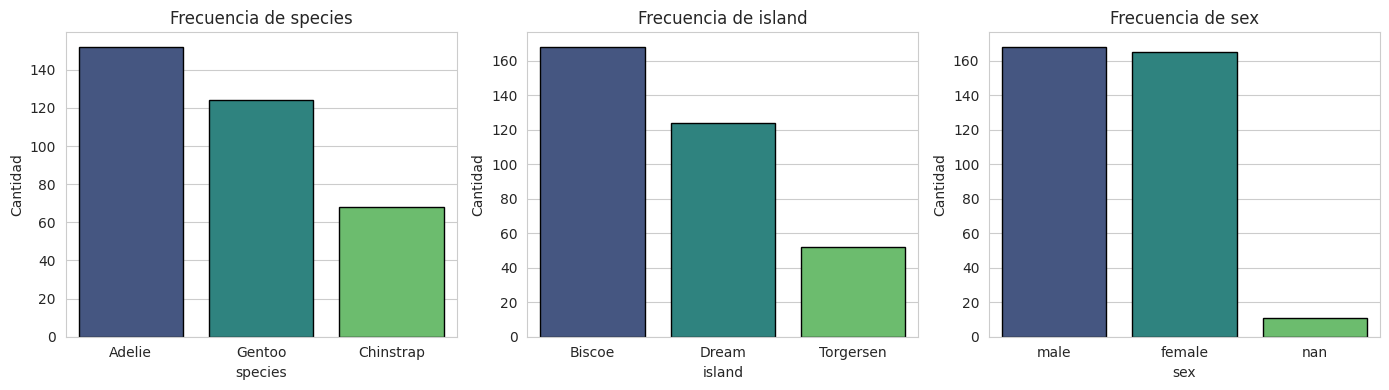

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['species', 'island', 'sex']):
    # Calculamos las frecuencias incluyendo nulos
    frecuencias = df[col].value_counts(dropna=False)
    colores = sns.color_palette('viridis', n_colors=len(frecuencias))

    sns.barplot(x=frecuencias.index.astype(str),
                y=frecuencias.values,
                palette=colores,
                edgecolor='black',
                ax=ax)

    ax.set_title(f'Frecuencia de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Cantidad')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**¿Qué hicimos?** Visualizamos la distribución de las tres variables categóricas con gráficos de barras. Confirmamos visualmente lo observado en las tablas de frecuencia: hay desbalance entre especies y entre islas, pero el sexo está bien equilibrado.

**Próximo paso**: avanzar al análisis bivariado para empezar a relacionar variables.

---
# 4. Análisis bivariado

El análisis bivariado estudia la relación entre dos variables. Las herramientas dependen de los tipos de variables involucradas:

- **Categórica vs. Categórica** → tabla de contingencia, gráfico de barras agrupadas.
- **Categórica vs. Numérica** → boxplots comparativos, gráficos de violín.
- **Numérica vs. Numérica** → diagrama de dispersión, coeficiente de Pearson.

## 4.1 Categórica vs. Categórica: especies por isla

¿Cómo se distribuyen las tres especies en las tres islas?

In [21]:
tabla_isla_especie = pd.crosstab(df['species'], df['island'])
tabla_isla_especie

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


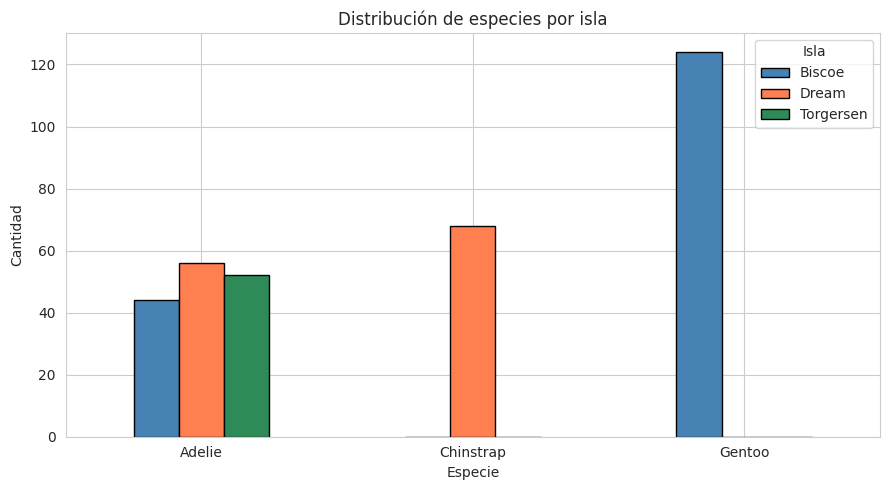

In [22]:
tabla_isla_especie.plot(kind='bar', stacked=False, figsize=(9, 5),
                         color=['steelblue', 'coral', 'seagreen'], edgecolor='black')
plt.title('Distribución de especies por isla')
plt.xlabel('Especie')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.legend(title='Isla')
plt.tight_layout()
plt.show()

Construimos una tabla de contingencia y la visualizamos como gráfico de barras agrupadas.  
El hallazgo:

- **Gentoo solo aparece en Biscoe** (124 individuos).
- **Chinstrap solo aparece en Dream** (68 individuos).
- **Adelie aparece en las tres islas** de manera relativamente pareja.

**Conclusión**: la distribución de especies por isla es muy desigual. Esto tiene una implicación importante para el análisis: si comparamos islas, en realidad estamos comparando especies, y viceversa. Las dos variables están fuertemente confundidas (entrelazadas), algo que conviene tener presente al interpretar resultados posteriores.

## 4.2 Categórica vs. Numérica: tamaño según especie

Aprovechando que ya identificamos a la especie como una variable clave, veamos cómo varían las medidas físicas entre especies.

In [23]:
df.groupby('species', observed=True)[variables_numericas].mean().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.79,18.35,189.95,3700.66
Chinstrap,48.83,18.42,195.82,3733.09
Gentoo,47.50,14.98,217.19,5076.02


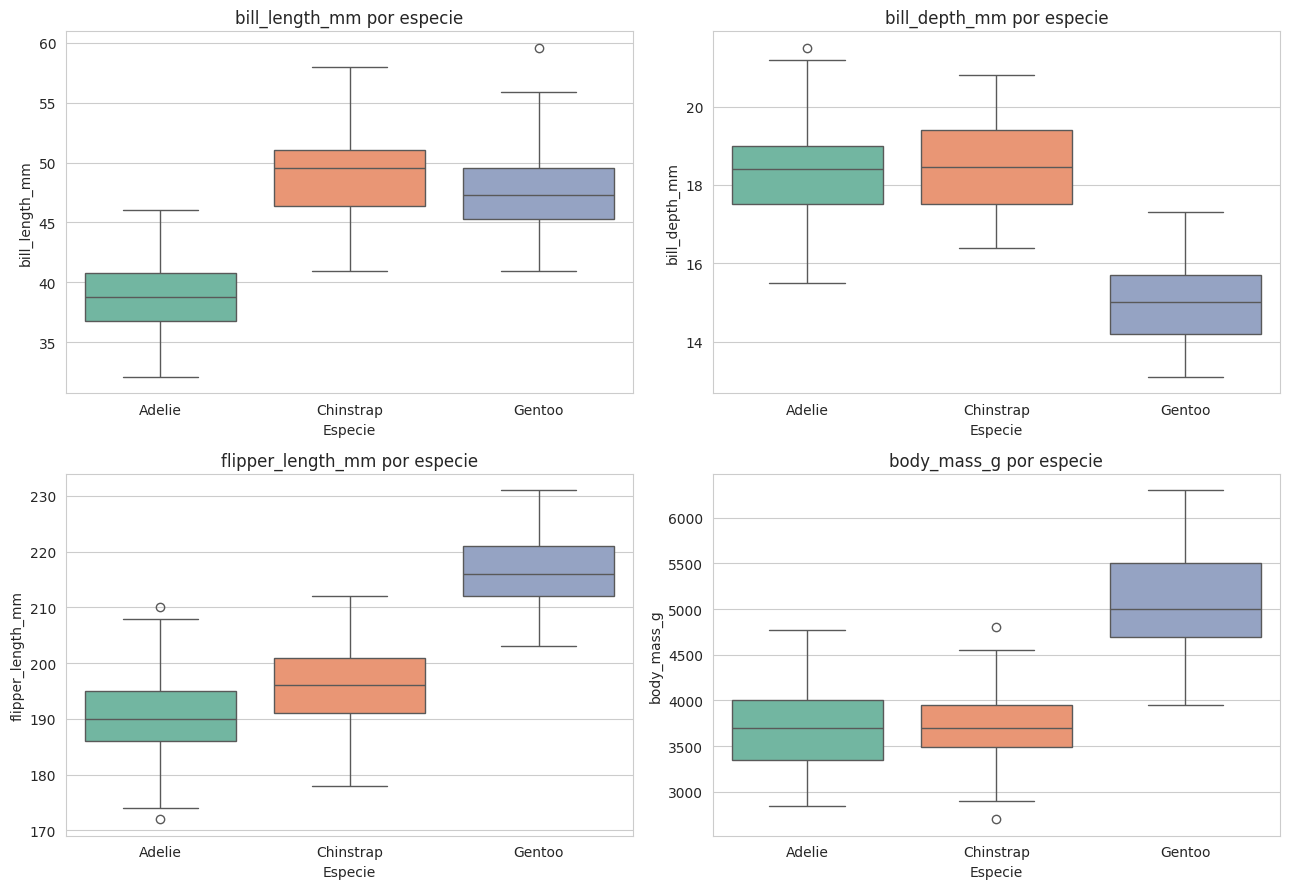

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, var in zip(axes.flatten(), variables_numericas):
    sns.boxplot(data=df, x='species', y=var, ax=ax, hue='species',
                palette='Set2', legend=False)
    ax.set_title(f'{var} por especie')
    ax.set_xlabel('Especie')

plt.tight_layout()
plt.show()

 Calculamos los promedios de cada medida por especie y visualizamos la distribución con boxplots comparativos.  
 Los hallazgos:

- **`bill_length_mm`**: los Adelie tienen picos notablemente más cortos (39 mm) que Chinstrap (49 mm) y Gentoo (47 mm).
- **`bill_depth_mm`**: los Gentoo tienen picos notablemente menos profundos (15 mm) que las otras dos especies (18 mm).
- **`flipper_length_mm`**: los Gentoo tienen aletas marcadamente más largas (217 mm) que Adelie y Chinstrap (190-196 mm).
- **`body_mass_g`**: los Gentoo son mucho más pesados (5076 g) que las otras dos especies (3700 g).

Tres patrones saltan a la vista:  

`Gentoo` es claramente la especie más grande: aletas más largas (217 mm) y mucho más pesada (5000 g), con poca superposición con las otras dos especies en ambas variables.  
`Gentoo` tiene picos menos profundos: su bill_depth_mm (14-15 mm) no se solapa en absoluto con `Adelie` y `Chinstrap` (ambas alrededor de 18-19 mm). Es la diferencia más limpia de las cuatro variables.  
`Adelie` y `Chinstrap` son similares en tamaño (peso y aleta prácticamente iguales), pero se distinguen por el largo del pico: `Chinstrap` tiene picos notablemente más largos (49 mm vs 39 mm de `Adelie`), sin superposición entre las cajas.  

Conclusión: cada especie tiene al menos una variable que la distingue con claridad del resto. Esto explica la bimodalidad que veíamos en los histogramas univariados: mezclábamos especies con morfologías distintas.

## 4.3 Categórica vs. Numérica: efecto del sexo

¿Hay diferencias entre machos y hembras?

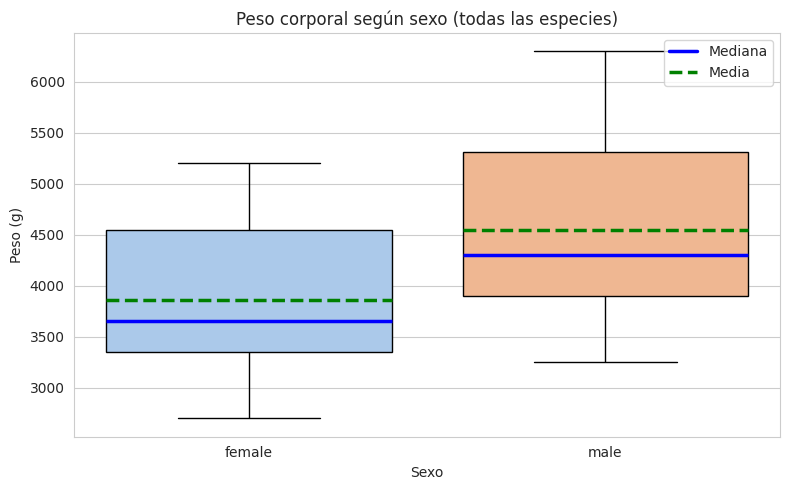

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

df_sin_nulos = df.dropna(subset=['sex'])

sns.boxplot(data=df_sin_nulos, x='sex', y='body_mass_g',
            hue='sex', palette='pastel', legend=False,
            medianprops=dict(color='blue', linewidth=2.5),
            boxprops=dict(edgecolor='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', markerfacecolor='gray',
                            markeredgecolor='black', markersize=5),
            ax=ax)

# Agregamos la media de cada grupo como línea horizontal verde
categorias = df_sin_nulos['sex'].cat.categories
for i, cat in enumerate(categorias):
    media = df_sin_nulos[df_sin_nulos['sex'] == cat]['body_mass_g'].mean()
    ax.hlines(media, xmin=i - 0.4, xmax=i + 0.4,
              color='green', linewidth=2.5, linestyle='--')

handles = [
    plt.Line2D([0], [0], color='blue',  linewidth=2.5,               label='Mediana'),
    plt.Line2D([0], [0], color='green', linewidth=2.5, linestyle='--', label='Media')
]
ax.legend(handles=handles, loc='upper right')

ax.set_title('Peso corporal según sexo (todas las especies)')
ax.set_xlabel('Sexo')
ax.set_ylabel('Peso (g)')
plt.tight_layout()
plt.show()

Comparamos el peso corporal entre machos y hembras a nivel global. Los machos tienden a ser más pesados, pero las distribuciones se solapan considerablemente. Esto puede deberse a que estamos mezclando especies de tamaños muy distintos.

**Próximo paso**: separar el análisis por especie para confirmar si la diferencia se mantiene dentro de cada grupo (esto ya es un análisis multivariado, lo veremos en la siguiente sección).

## 4.4 Numérica vs. Numérica: correlaciones

Para las cuatro variables numéricas, calculamos la matriz de correlación de Pearson.

In [27]:
matriz_corr = df[variables_numericas].corr().round(3)
matriz_corr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,-0.235,0.656,0.595
bill_depth_mm,-0.235,1.000,-0.584,-0.472
flipper_length_mm,0.656,-0.584,1.000,0.871
body_mass_g,0.595,-0.472,0.871,1.000


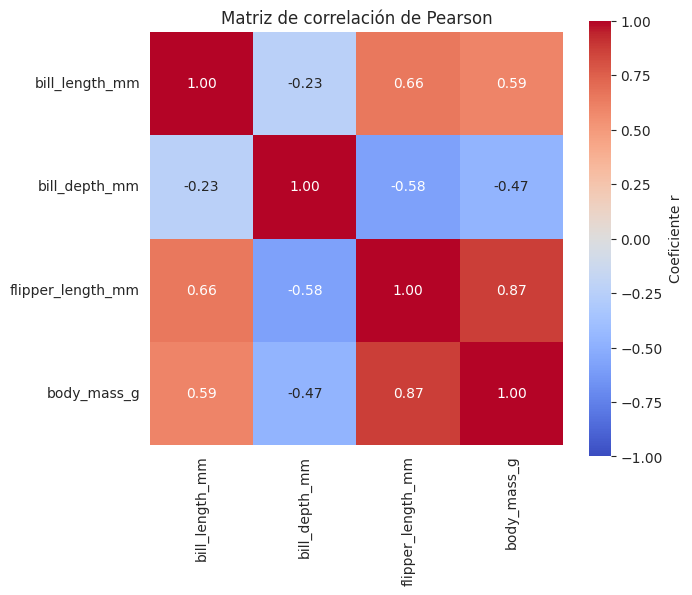

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', vmin=-1, vmax=1, ax=ax, square=True,
            cbar_kws={'label': 'Coeficiente r'})
ax.set_title('Matriz de correlación de Pearson')
plt.tight_layout()
plt.show()

Calculamos y visualizamos la matriz de correlación. Hallazgos:

- **`flipper_length_mm` y `body_mass_g`** tienen una correlación muy alta (r = 0,87): pingüinos con aletas más largas tienden a ser más pesados. Esto es esperable: la aleta es un buen indicador del tamaño general.
- **`bill_length_mm` y `flipper_length_mm`** tienen una correlación alta (r = 0,66): picos más largos suelen ir con aletas más largas.
- **`bill_length_mm` y `body_mass_g`** muestran correlación moderada (r = 0,59).
- **`bill_depth_mm` y `body_mass_g`** muestran una correlación negativa (r = -0,47): a mayor peso, menor profundidad de pico. Esto merece investigación. ¿Por qué un pingüino más pesado tendría un pico menos profundo?

**Atención al hallazgo contraintuitivo**: la relación negativa entre `bill_depth_mm` y `body_mass_g` puede estar siendo causada por el efecto de la especie (los Gentoo son grandes y tienen picos poco profundos, mientras que Adelie y Chinstrap son más chicos y tienen picos más profundos). Esto se explora en la siguiente sección.

## 4.5 Diagrama de dispersión

Visualizamos la relación más fuerte (`flipper_length_mm` vs `body_mass_g`).

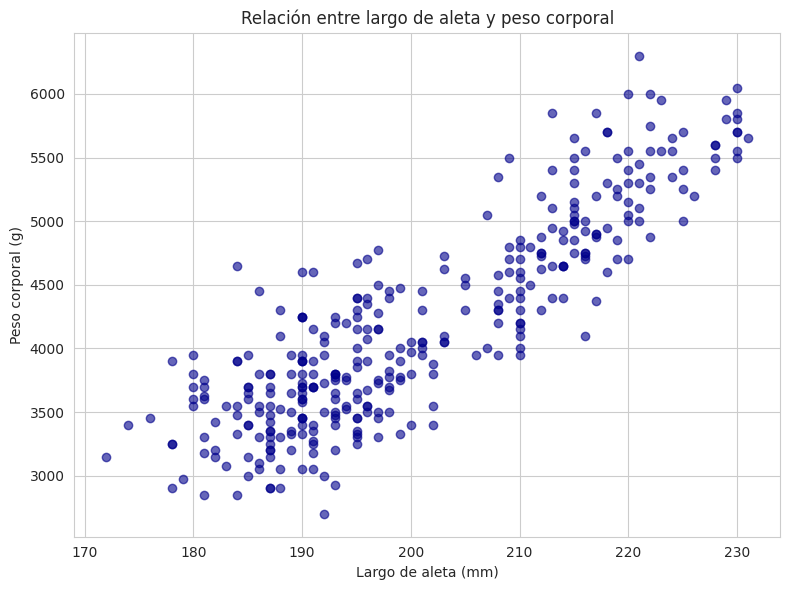

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['flipper_length_mm'], df['body_mass_g'], alpha=0.6, color='darkblue')
ax.set_xlabel('Largo de aleta (mm)')
ax.set_ylabel('Peso corporal (g)')
ax.set_title('Relación entre largo de aleta y peso corporal')
plt.tight_layout()
plt.show()

Visualizamos la relación lineal entre `flipper_length_mm` y `body_mass_g`. Se aprecia claramente la tendencia positiva, pero también se distinguen **dos nubes de puntos** separadas, lo que sugiere que en realidad hay subgrupos. Volvemos a encontrar pistas de heterogeneidad: el análisis multivariado será clave para terminar de entender el dataset.

---
# 5. Análisis multivariado

El análisis multivariado considera tres o más variables simultáneamente. Es donde se manifiestan las interacciones más interesantes y, a veces, donde aparecen sorpresas: relaciones que parecían claras en el análisis bivariado pueden cambiar de signo o desaparecer cuando se incorpora una tercera variable.

## 5.1 Diagrama de dispersión coloreado por especie

Retomemos el scatter de aleta vs. peso, pero ahora coloreando por especie.

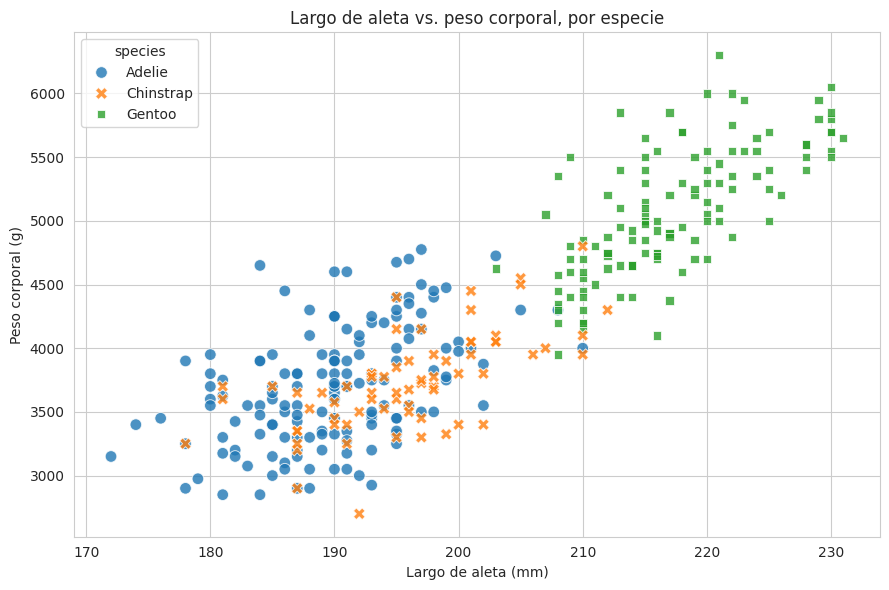

In [30]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g',
                hue='species', style='species', s=70, alpha=0.8, ax=ax)
ax.set_title('Largo de aleta vs. peso corporal, por especie')
ax.set_xlabel('Largo de aleta (mm)')
ax.set_ylabel('Peso corporal (g)')
plt.tight_layout()
plt.show()

Reproducimos el diagrama de dispersión incorporando la especie como una tercera dimensión, codificada en color y forma. Las dos nubes de puntos que veíamos antes ahora tienen explicación: los Gentoo (en una especie) ocupan la zona superior derecha (más grandes), mientras que Adelie y Chinstrap se mezclan en la zona inferior izquierda.

**Conclusión**: la relación positiva entre aleta y peso se mantiene tanto entre especies como dentro de cada especie, pero la magnitud y la posición de cada grupo es distinta.

## 5.2 La paradoja de Simpson: profundidad de pico vs. peso

Recordemos que la matriz de correlación mostró una **relación negativa** entre `bill_depth_mm` y `body_mass_g`. Veamos qué ocurre cuando separamos por especie.

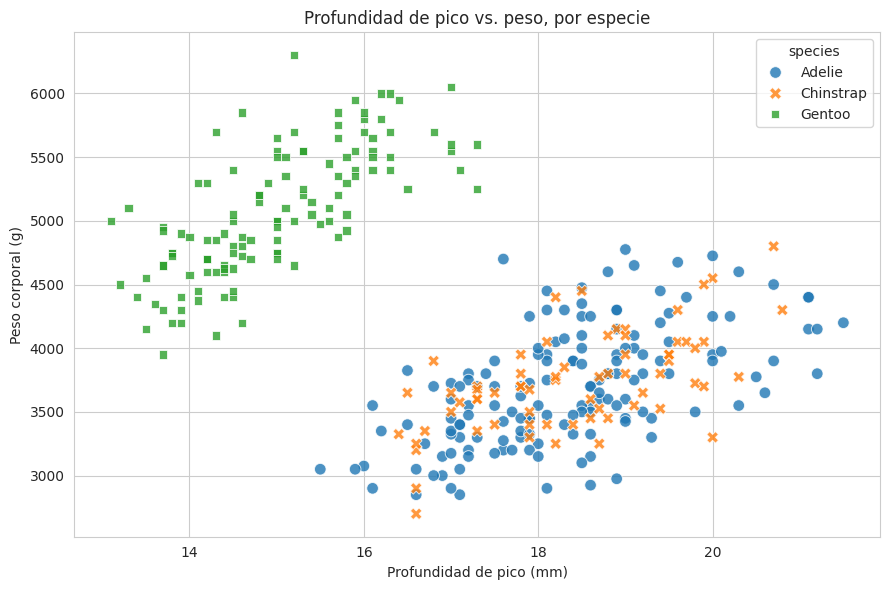

In [31]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x='bill_depth_mm', y='body_mass_g',
                hue='species', style='species', s=70, alpha=0.8, ax=ax)
ax.set_title('Profundidad de pico vs. peso, por especie')
ax.set_xlabel('Profundidad de pico (mm)')
ax.set_ylabel('Peso corporal (g)')
plt.tight_layout()
plt.show()

In [32]:
# Comparamos la correlación global con la correlación dentro de cada especie
print(f"Correlación GLOBAL: r = {df[['bill_depth_mm','body_mass_g']].corr().iloc[0,1]:.3f}")
print()
print('Correlación DENTRO de cada especie:')
for sp in df['species'].cat.categories:
    subset = df[df['species'] == sp]
    r = subset[['bill_depth_mm','body_mass_g']].corr().iloc[0,1]
    print(f'  {sp:10s}: r = {r:+.3f}')

Correlación GLOBAL: r = -0.472

Correlación DENTRO de cada especie:
  Adelie    : r = +0.576
  Chinstrap : r = +0.604
  Gentoo    : r = +0.719


El gráfico y los números muestran algo que parece contradictorio a primera vista:

- A nivel global: la correlación entre profundidad de pico y peso es negativa (r = -0,47). Es decir, mirando todos los pingüinos juntos, parecería que los más pesados tienen picos `menos` profundos.
- Dentro de cada especie: la correlación es positiva en los tres casos (r entre +0,58 y +0,71). Es decir, dentro de cada grupo, los pingüinos más pesados tienen picos `más` profundos.

¿Cómo puede ser negativa en el total y positiva en cada parte?  
Esto tiene nombre: se llama paradoja de Simpson.  

La clave está en los `Gentoo`. Esta especie es simultáneamente la más pesada y la que tiene picos menos profundos. Cuando mezclamos las tres especies en un solo gráfico sin distinguirlas, lo que domina la correlación es esa diferencia entre especies: `Gentoo` (pesados, picos poco profundos) vs. `Adelie` y `Chinstrap` (más livianos, picos más profundos). Esa diferencia entre grupos "aplasta" la tendencia real que existe dentro de cada grupo.
  
  El problema no es la correlación: es que estábamos mezclando grupos que no deberían mezclarse.  

**Lección importante**:  

Una correlación a nivel global puede ser radicalmente distinta a la correlación dentro de subgrupos. Antes de interpretar una correlación, conviene verificar si los datos contienen subgrupos heterogéneos. **Esta es una de las razones más importantes por las que el AED no se queda en el análisis bivariado**.

## 5.3 Pairplot: vista panorámica

El `pairplot` de seaborn genera una grilla con todos los diagramas de dispersión posibles entre pares de variables, más los histogramas (o KDE) en la diagonal. Es una forma compacta de obtener una vista panorámica del dataset.

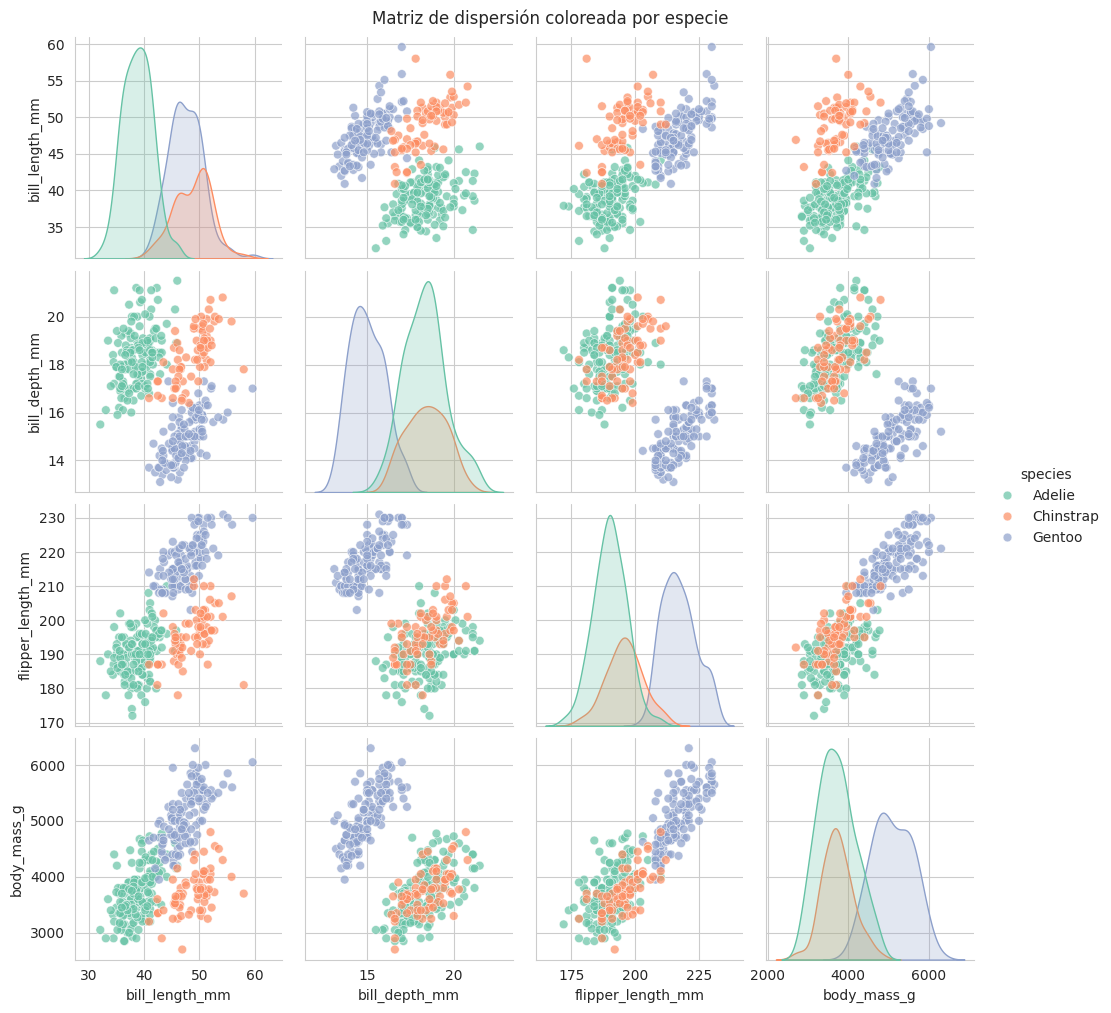

In [33]:
sns.pairplot(df.dropna(), hue='species', palette='Set2',
             vars=variables_numericas, diag_kind='kde',
             plot_kws={'alpha': 0.7, 's': 40})
plt.suptitle('Matriz de dispersión coloreada por especie', y=1.01)
plt.show()

Generamos una matriz de gráficos de dispersión que muestra todas las combinaciones de variables numéricas, coloreadas por especie. En la diagonal vemos la distribución de cada variable mediante KDE (estimación de densidad).

Esta vista panorámica confirma todo lo que veníamos viendo:

- Las especies forman **grupos claramente diferenciados** en casi todas las combinaciones de variables.
- Los Gentoo se separan especialmente bien por su mayor tamaño (peso, aleta) y menor profundidad de pico.
- Adelie y Chinstrap son más parecidos en tamaño, pero se diferencian sobre todo en el largo del pico.

**Conclusión**: las cuatro variables morfológicas, en conjunto, permiten distinguir las tres especies con claridad. Este es exactamente el tipo de hallazgo que justifica avanzar hacia un modelo de clasificación.

## 5.4 Dimorfismo sexual dentro de cada especie

Antes vimos que los machos tienden a ser más pesados, pero las distribuciones se solapaban. ¿Qué ocurre si comparamos sexo dentro de cada especie?

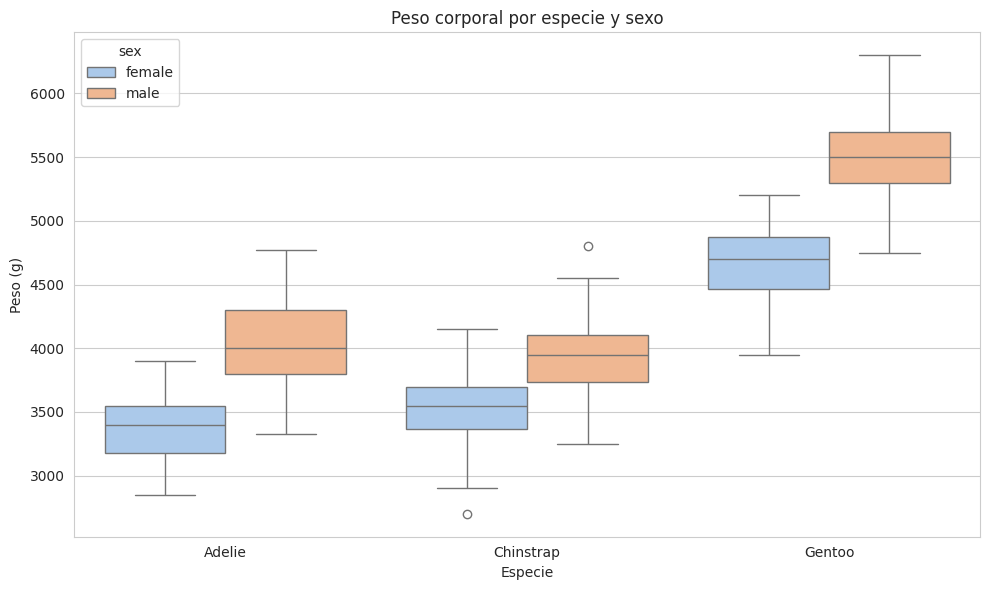

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df.dropna(subset=['sex']), x='species', y='body_mass_g',
            hue='sex', palette='pastel', ax=ax)
ax.set_title('Peso corporal por especie y sexo')
ax.set_xlabel('Especie')
ax.set_ylabel('Peso (g)')
plt.tight_layout()
plt.show()

In [35]:
df.dropna(subset=['sex']).groupby(['species','sex'], observed=True)['body_mass_g'].mean().round(0)

species    sex   
Adelie     female    3369.0
           male      4043.0
Chinstrap  female    3527.0
           male      3939.0
Gentoo     female    4680.0
           male      5485.0
Name: body_mass_g, dtype: float64

Comparamos el peso corporal por especie y sexo simultáneamente. Encontramos que dentro de cada especie los machos son sistemáticamente más pesados que las hembras:

- **Adelie**: hembras ~3369 g, machos ~4043 g (diferencia ~675 g).
- **Chinstrap**: hembras ~3527 g, machos ~3939 g (diferencia ~412 g).
- **Gentoo**: hembras ~4680 g, machos ~5485 g (diferencia ~805 g).

**Conclusión**: existe **dimorfismo sexual** en las tres especies, pero es más marcado en Gentoo y Adelie que en Chinstrap. Cuando antes mirábamos sexo sin distinguir especie, este patrón quedaba oscurecido por la mayor variabilidad entre especies. Otra confirmación de la importancia del análisis multivariado.

---
# 6. Síntesis y próximos pasos

## Hallazgos principales

1. **El dataset contiene tres subgrupos bien diferenciados** (Adelie, Chinstrap, Gentoo). La heterogeneidad entre especies se manifestó tempranamente como bimodalidad en los histogramas y como dos nubes en los diagramas de dispersión.
2. **Las especies están confundidas con las islas**: Gentoo solo aparece en Biscoe, Chinstrap solo en Dream. Cualquier comparación entre islas, en realidad, está comparando especies.
3. **Los Gentoo se diferencian morfológicamente**: son más grandes (peso, aleta) pero tienen picos menos profundos. Adelie y Chinstrap son más parecidos en tamaño pero se distinguen por el largo del pico.
4. **Existe dimorfismo sexual en las tres especies**: los machos son consistentemente más pesados que las hembras dentro de cada grupo.
5. **Caso de paradoja de Simpson**: la correlación entre profundidad de pico y peso es negativa a nivel global pero positiva dentro de cada especie. Es un recordatorio de que las correlaciones agregadas pueden ocultar o invertir las relaciones reales.

## Implicancias para los próximos pasos

- **Para un modelo de clasificación**: las cuatro variables morfológicas, combinadas con el sexo, parecen suficientes para discriminar las especies con alta precisión. Sería un buen caso para probar algoritmos como regresión logística, KNN o árboles de decisión.
- **Para profundizar**: explorar la variable `year` (¿cambian las medidas a lo largo del tiempo?), evaluar si los pocos valores faltantes en `sex` se pueden imputar a partir de las otras variables, y revisar si hay diferencias entre islas dentro de la única especie que aparece en las tres (Adelie).

---
# 7. Ejercicios para los estudiantes

Las siguientes consignas les permiten poner en práctica lo aprendido. Cada ejercicio incluye una pista sobre qué herramienta o tipo de análisis aplicar.

### Ejercicio 1: análisis univariado de una variable derivada

El dataset no incluye directamente una medida de la forma del pico, pero podemos construirla. La **relación entre el largo y la profundidad del pico** es un indicador morfológico relevante: un valor alto indica un pico largo y angosto, mientras que un valor bajo indica un pico corto y ancho.

Creen una nueva columna llamada `bill_ratio` que represente esa relación:

```python
df['bill_ratio'] = df['bill_length_mm'] / df['bill_depth_mm']
```

Una vez creada, realicen un análisis univariado completo:

1. Calculen las estadísticas descriptivas (media, mediana, cuartiles, mínimo y máximo).
2. Visualicen su distribución con un histograma con curva KDE.
3. Detecten valores atípicos con un boxplot, marcando la media y la mediana.
4. Redacten una breve conclusión: ¿la distribución es simétrica o asimétrica? ¿hay outliers? ¿esperarían que esta variable varíe entre especies? ¿por qué?

*Pista*: recuerden usar las versiones con seaborn que trabajamos en clase: `sns.histplot()` con `kde=True` y `sns.boxplot()` con `ax.hlines()` para la media.

In [ ]:
# Resolución del ejercicio 1


### Ejercicio 2: comparación entre grupos

¿Existen diferencias en `bill_length_mm` entre las tres islas? ¿Y entre los dos sexos?

1. Construyan un boxplot comparativo de `bill_length_mm` según `island`.
2. Construyan otro boxplot comparativo según `sex`.
3. Calculen los promedios por grupo en ambos casos.
4. Interpreten los resultados. **Atención**: recuerden que las especies están distribuidas de forma desigual entre las islas. ¿Cómo afecta eso a la interpretación?

*Pista*: pueden usar `sns.boxplot()` y `df.groupby('variable')['bill_length_mm'].mean()`.

In [ ]:
# Resolución del ejercicio 2


### Ejercicio 3: relación bivariada y multivariada

Investiguen la relación entre `flipper_length_mm` y `bill_depth_mm`:

1. Calculen la correlación de Pearson entre ambas variables a nivel global.
2. Construyan un diagrama de dispersión simple, sin distinguir grupos.
3. Construyan otro diagrama de dispersión coloreado por especie.
4. Calculen la correlación de Pearson **dentro de cada especie**.
5. Comparen los resultados: ¿la correlación global y las correlaciones por especie van en el mismo sentido? ¿Qué está causando esa diferencia? ¿Qué conclusión sacan sobre el riesgo de interpretar correlaciones sin considerar subgrupos?

*Pista*: antes de agregar el color al scatter, anoten cuál esperarían que sea el signo de la correlación y por qué. Después contrasten esa hipótesis con lo que encuentran al separar por especie. Si ya vieron la sección 5.2 del notebook, este ejercicio debería resultarles familiar.

In [ ]:
# Resolución del ejercicio 3


---
## Cierre

Este notebook recorrió el flujo típico de un AED: desde la inspección inicial y el control de calidad de los datos, pasando por el análisis univariado y bivariado, hasta el análisis multivariado donde aparecen las interacciones más sutiles.

Los tres pilares del AED, vistos en clase, se aplicaron en cada paso:

1. **Explorar y comprender la naturaleza de los datos**: revisamos tipos, faltantes, distribuciones y outliers.
2. **Apoyar la preparación del modelo**: identificamos variables predictoras potentes (especialmente la especie) y descubrimos que las correlaciones globales pueden ser engañosas en presencia de subgrupos.
3. **Articular el análisis gráfico y el numérico**: cada estadístico fue acompañado por una visualización, y cada visualización derivó en una conclusión cuantificada.

El AED no terminó respondiendo preguntas definitivas, sino formulando mejores preguntas para las próximas etapas del análisis. Tal como decía Tukey: *"el análisis exploratorio puede sugerir lo que debes preguntar, no solo responder lo que ya sabes"*.